# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [5]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

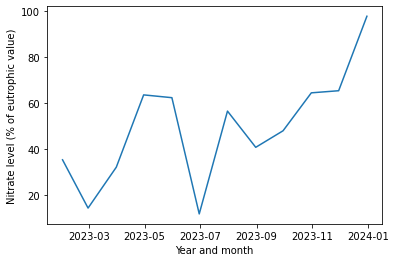

In [6]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

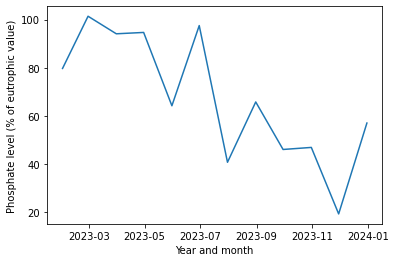

In [7]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<AxesSubplot:>

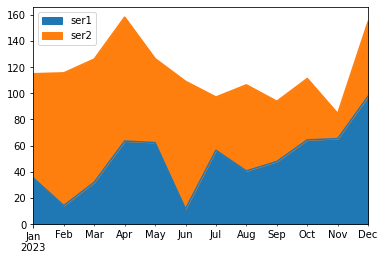

In [8]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [9]:
#first dataset: airbnb

file_path = "/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/cleaned_airbnb_data.csv" 
df = pd.read_csv(file_path)

print(df.info())   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14448 entries, 0 to 14447
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14448 non-null  int64  
 1   name                            14448 non-null  object 
 2   host_id                         14448 non-null  int64  
 3   host_name                       14448 non-null  object 
 4   neighbourhood                   14448 non-null  object 
 5   latitude                        14448 non-null  float64
 6   longitude                       14448 non-null  float64
 7   room_type                       14448 non-null  object 
 8   price                           14448 non-null  float64
 9   minimum_nights                  14448 non-null  int64  
 10  number_of_reviews               14448 non-null  int64  
 11  last_review                     12243 non-null  object 
 12  reviews_per_month               

In [81]:
print(df.describe())

                 id       host_id      latitude     longitude         price  \
count  1.444800e+04  1.444800e+04  14448.000000  14448.000000  14448.000000   
mean   6.503929e+17  2.629798e+08     37.979759     23.731557    102.488511   
std    5.126036e+17  2.033378e+08      0.013218      0.012301    298.296816   
min    2.726200e+04  1.805000e+03     37.950322     23.700809     10.000000   
25%    4.209198e+07  7.434376e+07     37.968709     23.724078     50.000000   
50%    8.374545e+17  2.150911e+08     37.978370     23.729710     69.000000   
75%    1.120451e+18  4.663443e+08     37.987441     23.737137    100.000000   
max    1.318602e+18  6.683661e+08     38.030830     23.780220  15200.000000   

       minimum_nights  number_of_reviews  reviews_per_month  \
count    14448.000000       14448.000000       14448.000000   
mean         2.524086          53.649432           1.642213   
std         10.516612          93.553634           1.596510   
min          1.000000           0.00

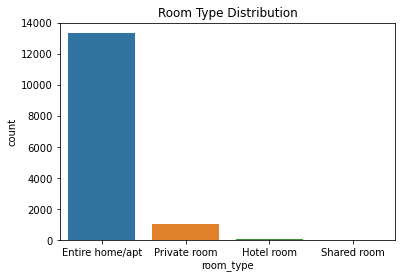

In [83]:
sns.countplot(x='room_type', data=df)
plt.title('Room Type Distribution')
plt.show()

In [10]:
correlations = df.corr()
print(correlations)

                                      id   host_id  latitude  longitude  \
id                              1.000000  0.486182  0.042245   0.013495   
host_id                         0.486182  1.000000  0.051831  -0.008410   
latitude                        0.042245  0.051831  1.000000   0.188435   
longitude                       0.013495 -0.008410  0.188435   1.000000   
price                           0.023580  0.022041 -0.043723  -0.000190   
minimum_nights                 -0.050254 -0.051278  0.028237   0.014522   
number_of_reviews              -0.504004 -0.297960 -0.101147  -0.092723   
reviews_per_month              -0.023758 -0.044649 -0.121115  -0.131877   
calculated_host_listings_count  0.064332 -0.139830 -0.051897  -0.022067   
availability_365                0.055573  0.014607 -0.052445  -0.016377   
number_of_reviews_ltm          -0.214262 -0.141394 -0.114815  -0.118276   
room_type_Entire home/apt       0.010561 -0.040723 -0.089630   0.015947   
room_type_Hotel room     

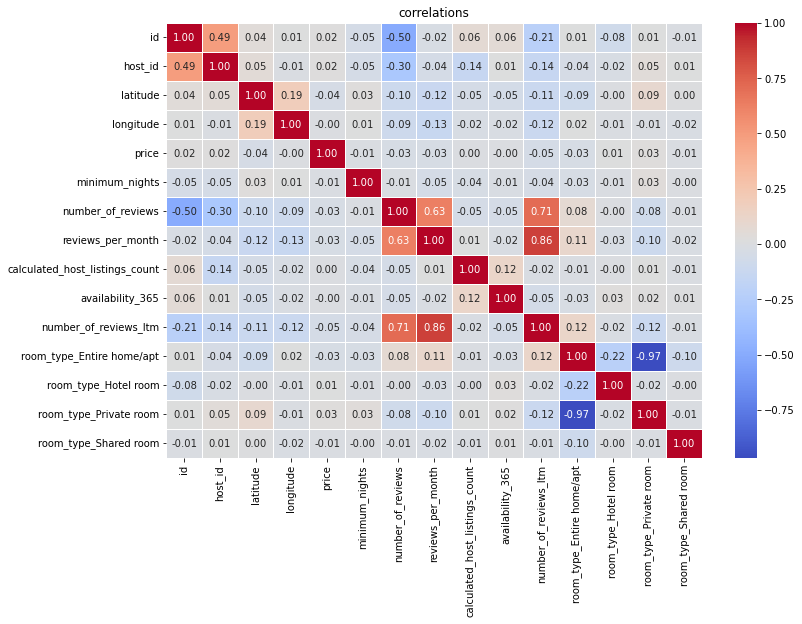

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('correlations')
plt.show()

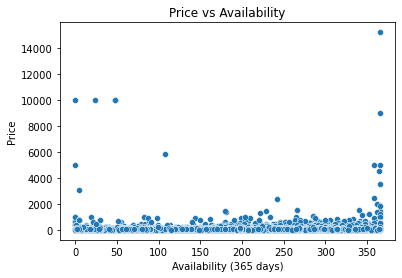

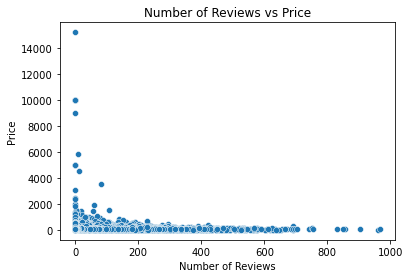

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatterplot: Price vs Availability
sns.scatterplot(data=df, x='availability_365', y='price')
plt.title('Price vs Availability')
plt.xlabel('Availability (365 days)')
plt.ylabel('Price')
plt.show()

# Scatterplot: Number of reviews vs Price
sns.scatterplot(data=df, x='number_of_reviews', y='price')
plt.title('Number of Reviews vs Price')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')
plt.show()

A significant number of listings have very few or zero reviews. These listings may be new, or they may be less popular, hence not getting many reviews. And people pay higher price, but most of them do not review.

A lot of listings have availability set at 365 days (which means they are available year-round), and the price doesn't vary significantly.

many listings are available for the full year (365 days) and have stable prices, but the few high-priced outliers at both low and high availability reflect properties that either have limited availability due to exclusivity or high demand or offer a consistent price throughout the year.

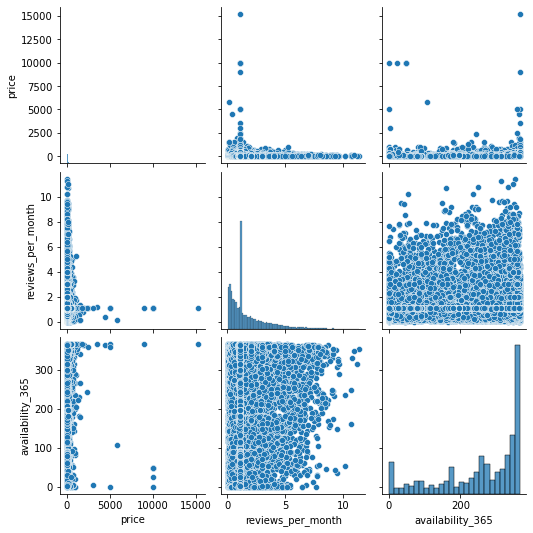

In [13]:
# Pairplot for selected numerical features
sns.pairplot(df[['price', 'reviews_per_month', 'availability_365']])
plt.show()

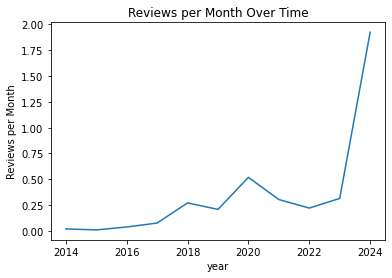

In [14]:
# Convert 'last_review' to datetime
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Group by year or month and calculate average 'reviews_per_month'
df['year'] = df['last_review'].dt.year
reviews_by_year = df.groupby('year')['reviews_per_month'].mean()

# Line plot to see trend over time
reviews_by_year.plot(kind='line', title='Reviews per Month Over Time', ylabel='Reviews per Month')
plt.show()

Probably they got popular with time.

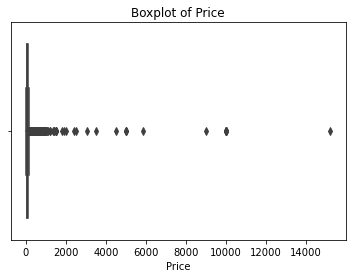

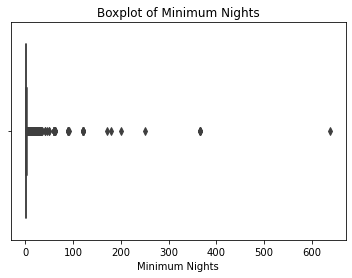

In [15]:
# Boxplot to detect outliers in 'price'
sns.boxplot(data=df, x='price')
plt.title('Boxplot of Price')
plt.xlabel('Price')
plt.show()

# Boxplot for minimum_nights
sns.boxplot(data=df, x='minimum_nights')
plt.title('Boxplot of Minimum Nights')
plt.xlabel('Minimum Nights')
plt.show()

On the price boxplot the outliers are really high.



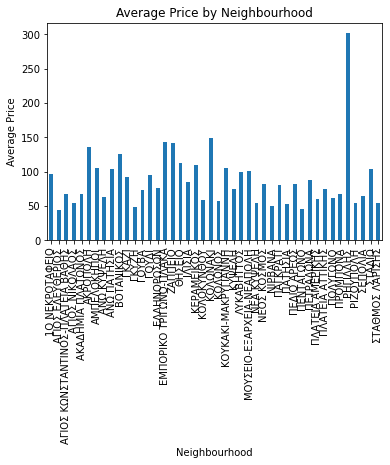

In [16]:
# Group by neighbourhood to analyze price variations
price_by_neighbourhood = df.groupby('neighbourhood')['price'].mean()

# Barplot of average price by neighbourhood
price_by_neighbourhood.plot(kind='bar', title='Average Price by Neighbourhood', xlabel='Neighbourhood', ylabel='Average Price')
plt.show()

The bars reflects the diversity of neighbourhoods. For example, certain areas (like city centres or tourist hotspots) may have much higher prices compared to suburban or less touristy areas.

In [17]:
# 2nd dataset

file_path_austin = "/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/cleaned_austin_data.csv" 
austin_df = pd.read_csv(file_path_austin )

print(austin_df.info())   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15171 entries, 0 to 15170
Data columns (total 55 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   zpid                            15171 non-null  int64  
 1   city                            15171 non-null  object 
 2   streetAddress                   15171 non-null  object 
 3   zipcode                         15171 non-null  int64  
 4   description                     15171 non-null  object 
 5   latitude                        15171 non-null  float64
 6   longitude                       15171 non-null  float64
 7   propertyTaxRate                 15171 non-null  float64
 8   garageSpaces                    15171 non-null  int64  
 9   hasAssociation                  15171 non-null  bool   
 10  hasCooling                      15171 non-null  bool   
 11  hasGarage                       15171 non-null  bool   
 12  hasHeating                      

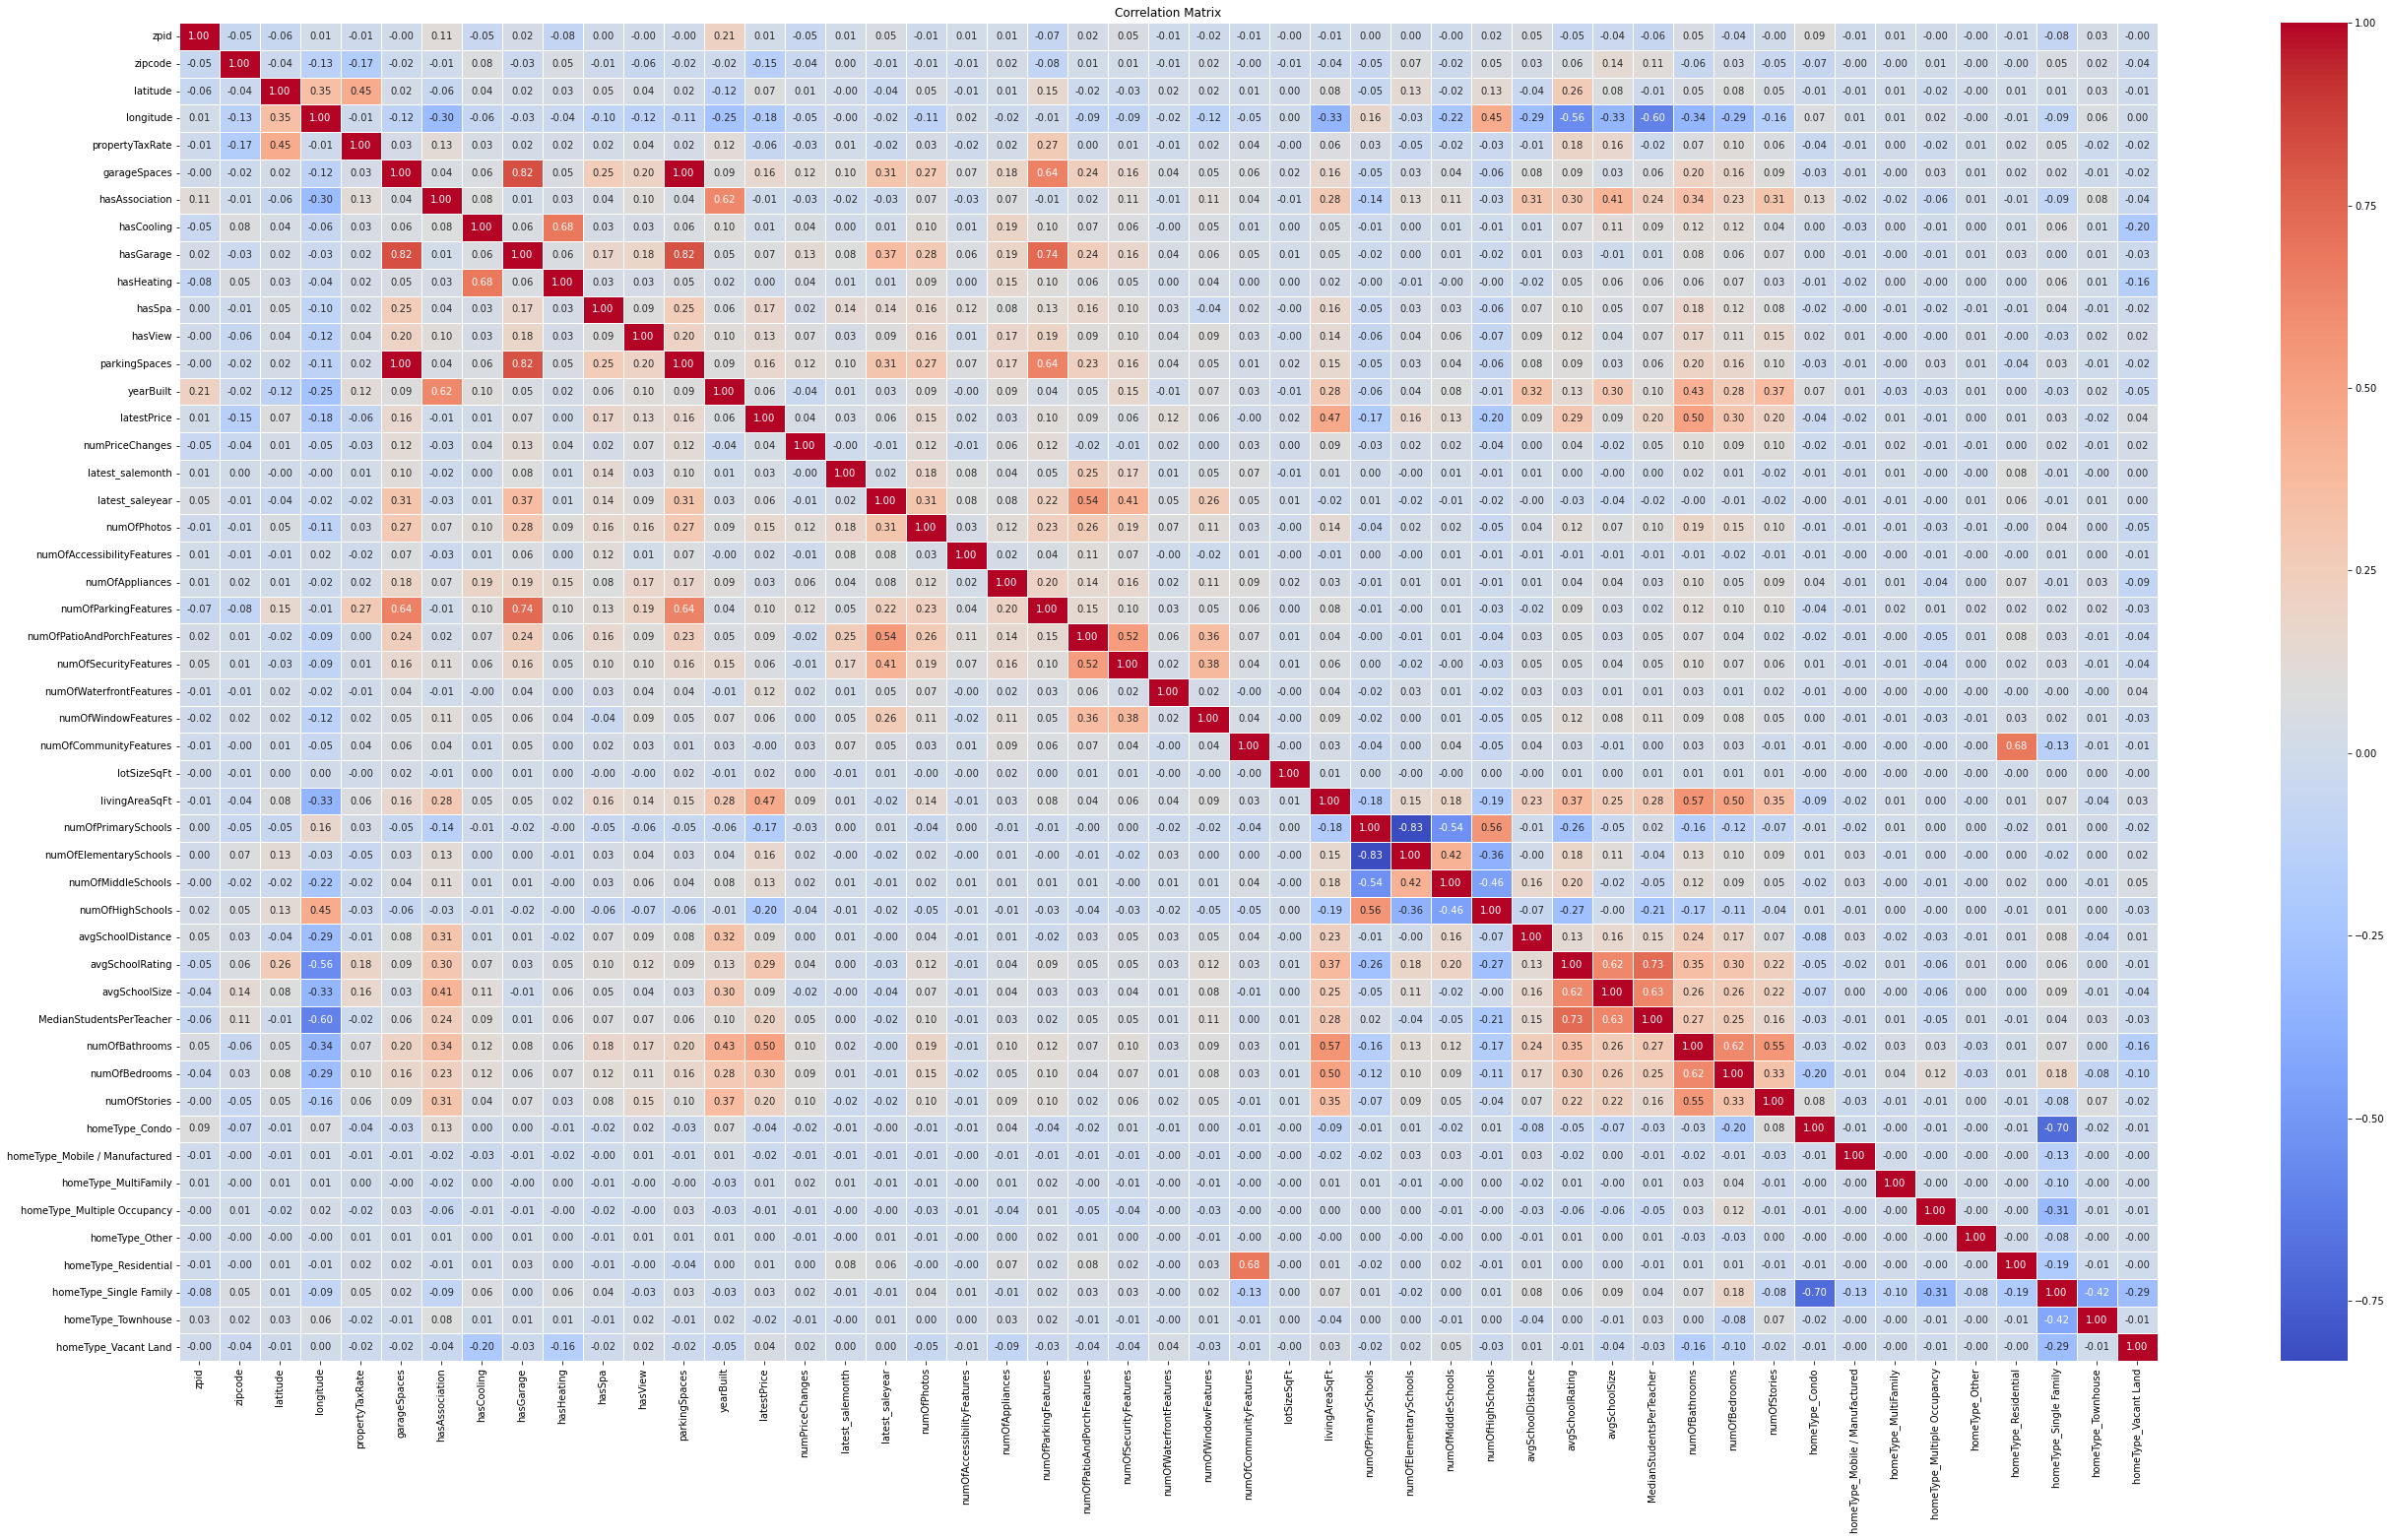

In [25]:
correlation_matrix = austin_df.corr()

plt.figure(figsize=(45,25))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [30]:
bool_columns = ['hasAssociation', 'hasCooling', 'hasGarage', 'hasHeating', 'hasSpa', 'hasView']
austin_df[bool_columns] = austin_df[bool_columns].astype(int)

austin_df['latest_saledate'] = pd.to_datetime(austin_df['latest_saledate'])

categorical_columns = ['city', 'streetAddress', 'description', 'latestPriceSource', 'homeImage']
austin_df[categorical_columns] = austin_df[categorical_columns].astype('object')


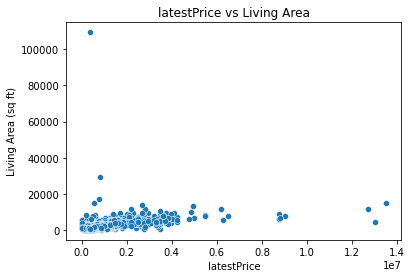

In [42]:
#Scatterplots for highly correlated variables (example: lotSizeSqFt vs livingAreaSqFt)
sns.scatterplot(x='latestPrice', y='livingAreaSqFt', data=austin_df)
plt.title('latestPrice vs Living Area')
plt.xlabel('latestPrice')
plt.ylabel('Living Area (sq ft)')
plt.show()

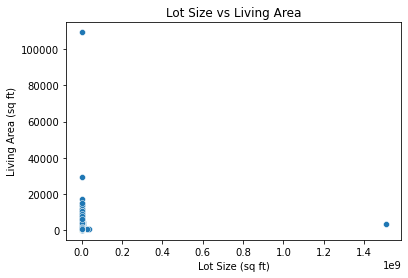

In [41]:
#Scatterplots for highly correlated variables (example: lotSizeSqFt vs livingAreaSqFt)
sns.scatterplot(x='lotSizeSqFt', y='livingAreaSqFt', data=austin_df)
plt.title('Lot Size vs Living Area')
plt.xlabel('Lot Size (sq ft)')
plt.ylabel('Living Area (sq ft)')
plt.show()

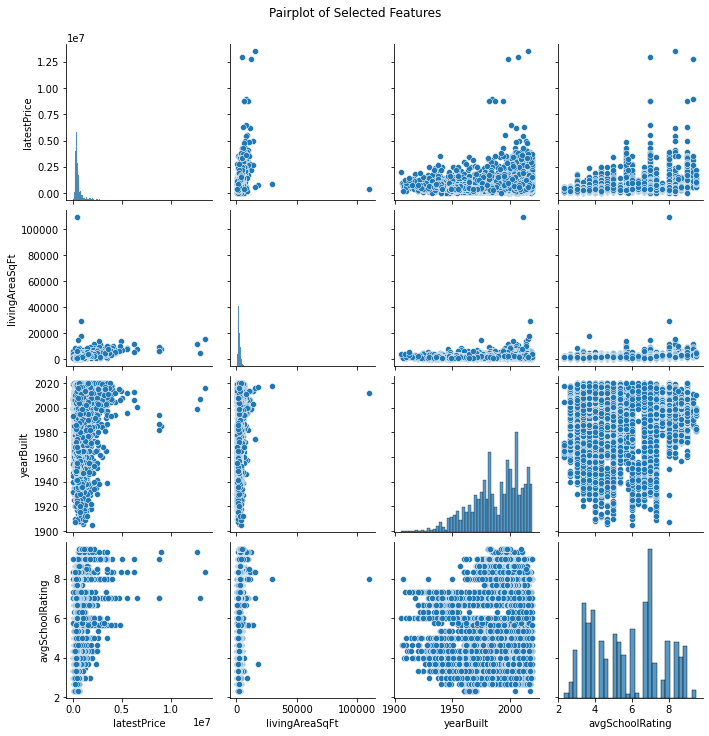

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select columns of interest for the pairplot
selected_columns = ['latestPrice','livingAreaSqFt','yearBuilt', 'avgSchoolRating']

# Create a pairplot
sns.pairplot(austin_df[selected_columns])
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()

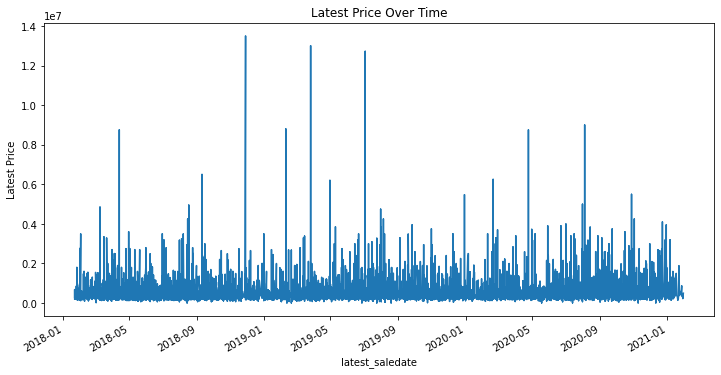

In [43]:
#Line plot for `latestPrice` over time
austin_df['latest_saledate'] = pd.to_datetime(austin_df['latest_saledate'])  # Convert to datetime
austin_df.set_index('latest_saledate', inplace=True)  # Set date as index
austin_df['latestPrice'].plot(figsize=(12, 6), title='Latest Price Over Time')
plt.ylabel('Latest Price')
plt.show()

Pretty high prices from 2019/01- 2019/09, meaning these are outliers.


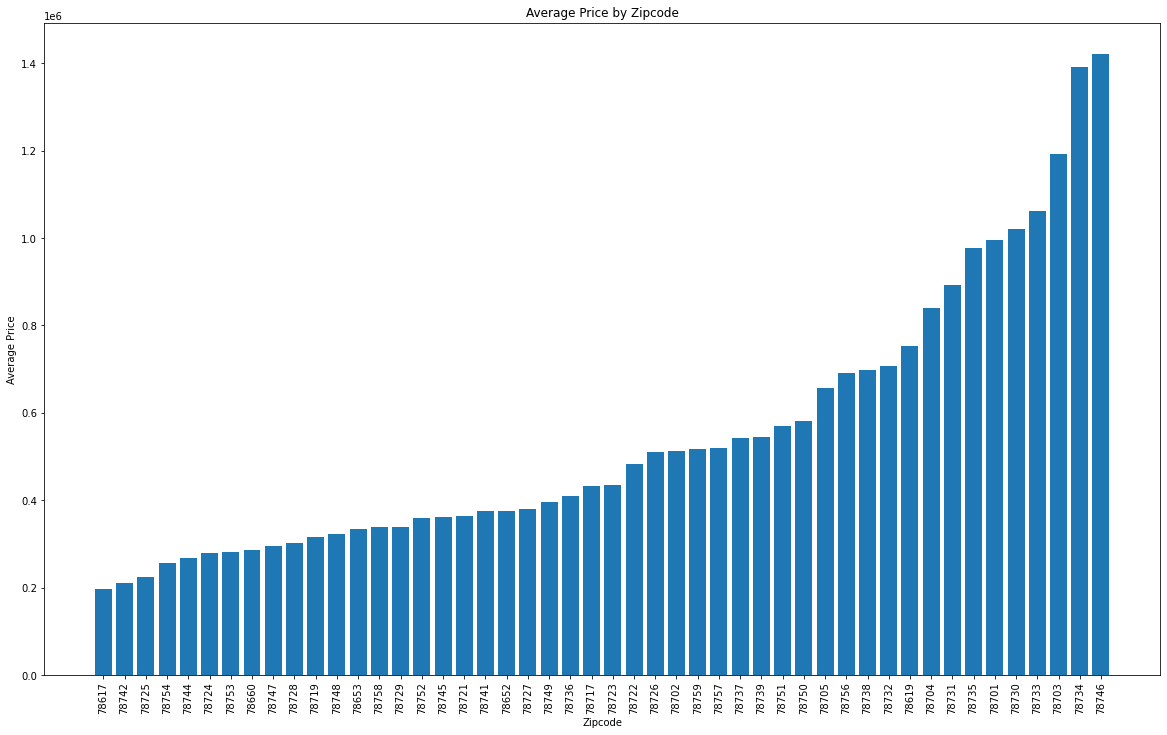

In [80]:
# Calculate the average price of each zipcode
avg_price_by_zipcode = austin_df.groupby('zipcode')['latestPrice'].mean().sort_values()

# Create a bar chart
fig, ax = plt.subplots(figsize=(20,12))
ax.bar(avg_price_by_zipcode.index.astype(str), avg_price_by_zipcode.values)
ax.set_xlabel('Zipcode')
ax.set_ylabel('Average Price')
ax.set_title('Average Price by Zipcode')
plt.xticks(rotation=90)
plt.show()

In [44]:
#Check for missing values
print(df.isnull().sum())

id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       2205
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                              0
room_type_Entire home/apt            0
room_type_Hotel room                 0
room_type_Private room               0
room_type_Shared room                0
year                              2205
dtype: int64


So there are some missing values on last_review, year , surprisingly same amount.

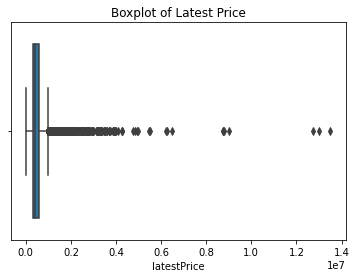

In [46]:
# Check for outliers using boxplot : latestPrice
sns.boxplot(x=austin_df['latestPrice'])
plt.title('Boxplot of Latest Price')
plt.show()

In [47]:
#Check for redundant columns by looking at correlations
# we can filter out columns that have a very high correlation, e.g., correlation > 0.95
high_corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[high_corr_pairs != 1]
print(high_corr_pairs)

garageSpaces            parkingSpaces               0.997321
parkingSpaces           garageSpaces                0.997321
garageSpaces            hasGarage                   0.822110
hasGarage               garageSpaces                0.822110
                        parkingSpaces               0.818608
                                                      ...   
longitude               MedianStudentsPerTeacher   -0.597129
homeType_Condo          homeType_Single Family     -0.699688
homeType_Single Family  homeType_Condo             -0.699688
numOfElementarySchools  numOfPrimarySchools        -0.832492
numOfPrimarySchools     numOfElementarySchools     -0.832492
Length: 2352, dtype: float64


3rd dataset: real estate dataset

In [64]:
file_path_real_estate = "/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/updated_real_estate.csv" 
real_estate_df = pd.read_csv(file_path_real_estate)

print(real_estate_df.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2223239 entries, 0 to 2223238
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   status             object 
 1   price              float64
 2   bed                float64
 3   bath               float64
 4   acre_lot           float64
 5   city               object 
 6   state              object 
 7   zip_code           float64
 8   house_size         float64
 9   prev_sold_date     object 
 10  prev_sold_encoded  int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 186.6+ MB
None


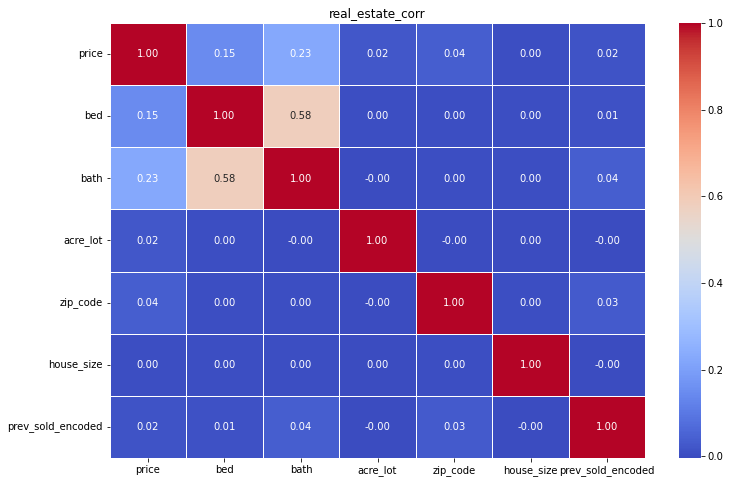

In [65]:
real_estate_corr = real_estate_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(real_estate_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('real_estate_corr')
plt.show()

The correlations are not that hight. House size has no correlation with price, which is very surprising. Could mean price depend more on other features than house size.


Correlation Expectations: In a typical real estate dataset, higher correlations between variables are expected like:
Price and House Size (strong positive correlation)
Price and Bedrooms / Bathrooms (moderate to strong positive correlation)
Price and Lot Size (moderate to weak positive correlation)

These low correlations could indicate that the dataset might be problematic, with either poor feature representation, missing relevant data, or an unrepresentative sample of properties.

Usability Issues: With low correlation between key features like price and house size, and between price and the number of bedrooms or bathrooms, it's concerning. In typical real estate data, these features (especially house size, bedrooms, and bathrooms) are crucial for determining the price. The fact that these correlations are weak suggests:

Possible data quality issues: There could be missing or incorrect data, or these features might not have been captured correctly in the dataset.

Outliers or skewed data: There could be outliers or skewed distributions that are masking the real relationships between the variables. It's essential to check for outliers, perform normalization, or transformation of features.

In [66]:
re_florida = real_estate_df[real_estate_df['state'] == 'Florida']
re_florida.head(5)

,status,price,bed,bath,acre_lot,city,state,zip_code,house_size,prev_sold_date,prev_sold_encoded
303141,for_sale,1500000.0,3.0,2.0,16.50,Malabar,Florida,32950.0,1200.0,No,0
354319,for_sale,349000.0,3.0,2.0,1.33,Palm Bay,Florida,32905.0,1200.0,No,0
412992,for_sale,275000.0,6.0,4.0,0.17,Hilliard,Florida,32046.0,2368.0,Yes,1
413009,for_sale,285000.0,3.0,2.0,0.26,Yulee,Florida,32097.0,1635.0,Yes,1
413010,for_sale,644000.0,4.0,4.0,0.17,Fernandina Beach,Florida,32034.0,2814.0,No,0


<AxesSubplot:xlabel='city'>

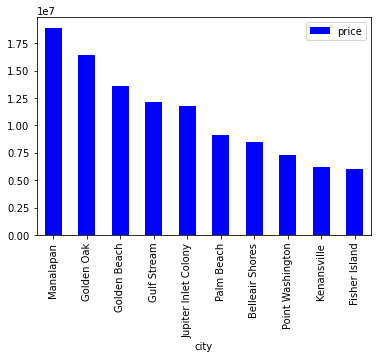

In [59]:
# top 10 high priced city's in florida

mean_price_city = re_florida.groupby('city')['price'].mean()
mean_price_city = pd.DataFrame(mean_price_city)
high_price_mean = mean_price_city.sort_values(['price'], ascending = False)
high_price_mean = high_price_mean.head(10)
high_price_mean.plot(kind = 'bar', color = 'blue')

In [67]:
price_range = ((max(real_estate_df.price))-(min(real_estate_df.price)))
price_range

1000000000.0

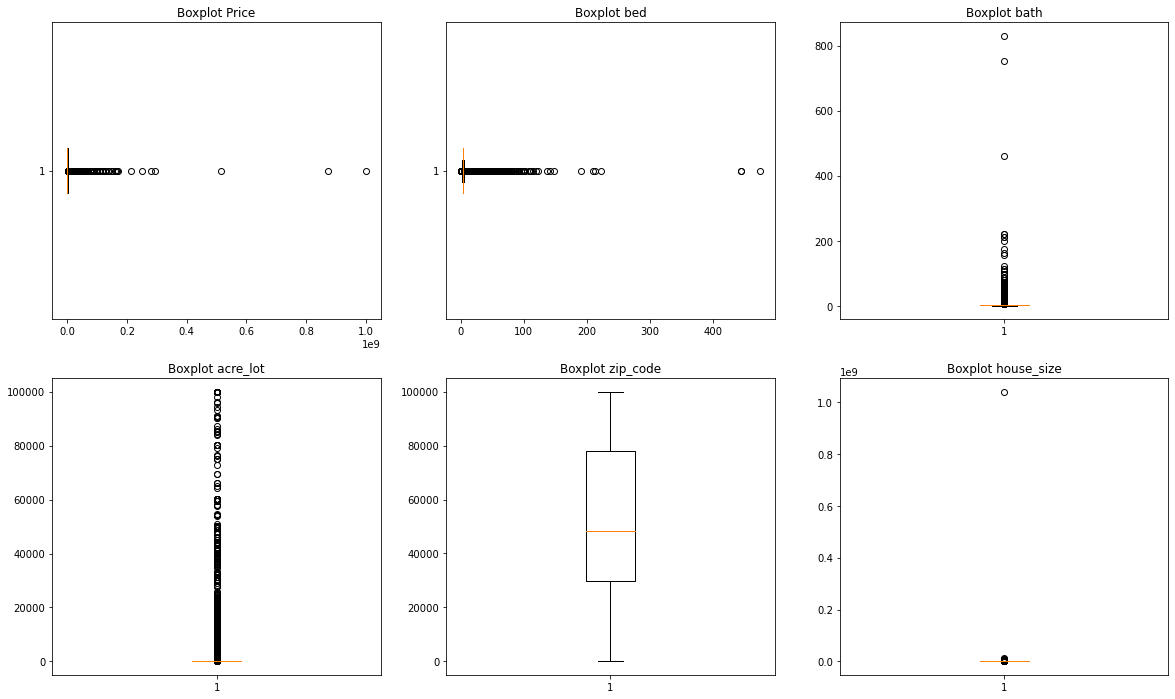

In [77]:
# Finding outliers using boxplot
fig, axs = plt.subplots(2, 3, figsize=(20, 12))

axs[0, 0].boxplot(real_estate_df.price, vert= 0)
axs[0, 0].set_title('Boxplot Price')

axs[0, 1].boxplot(real_estate_df.bed, vert= 0)
axs[0, 1].set_title('Boxplot bed')

axs[0, 2].boxplot(real_estate_df.bath)
axs[0, 2].set_title('Boxplot bath')

axs[1, 0].boxplot(real_estate_df.acre_lot)
axs[1, 0].set_title('Boxplot acre_lot')

axs[1, 1].boxplot(real_estate_df.zip_code)
axs[1, 1].set_title('Boxplot zip_code')

axs[1, 2].boxplot(real_estate_df.house_size)
axs[1, 2].set_title('Boxplot house_size');

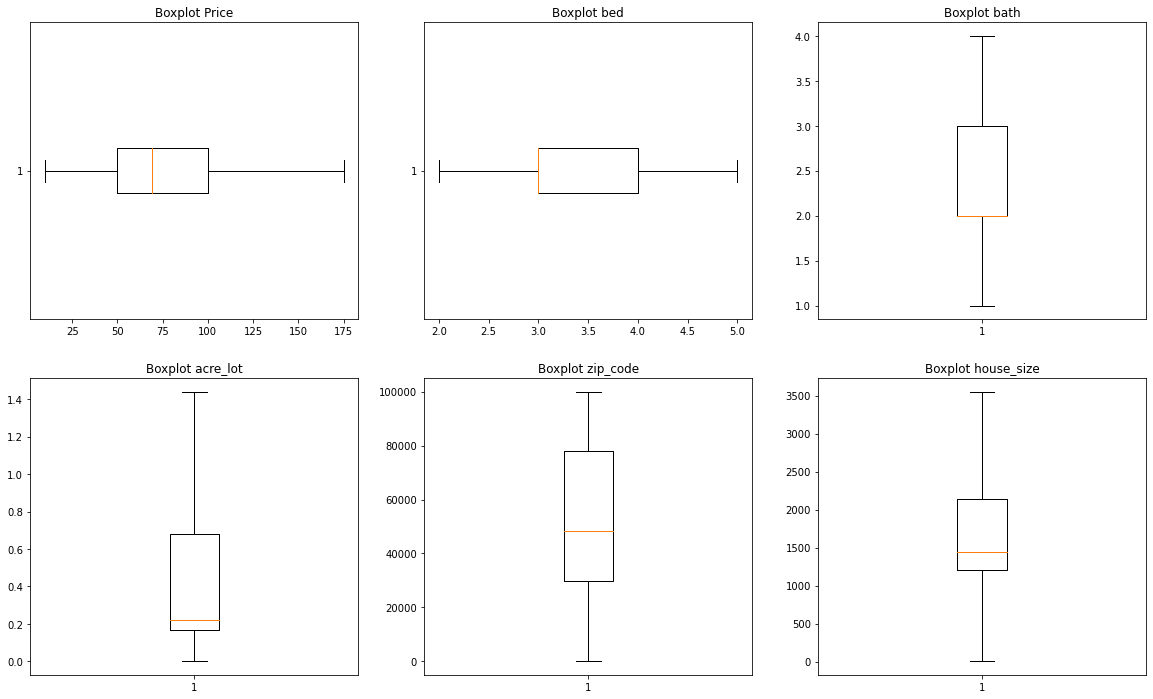

In [79]:
# visualize outliers of numerical columns

fig, axs = plt.subplots(2, 3, figsize=(20, 12))

axs[0, 0].boxplot(df.price, vert= 0, showfliers=False)
axs[0, 0].set_title('Boxplot Price')

axs[0, 1].boxplot(real_estate_df.bed, vert= 0,showfliers=False)
axs[0, 1].set_title('Boxplot bed')

axs[0, 2].boxplot(real_estate_df.bath,showfliers=False)
axs[0, 2].set_title('Boxplot bath')

axs[1, 0].boxplot(real_estate_df.acre_lot, showfliers=False)
axs[1, 0].set_title('Boxplot acre_lot')

axs[1, 1].boxplot(real_estate_df.zip_code, showfliers=False)
axs[1, 1].set_title('Boxplot zip_code')

axs[1, 2].boxplot(real_estate_df.house_size, showfliers=False)
axs[1, 2].set_title('Boxplot house_size');

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

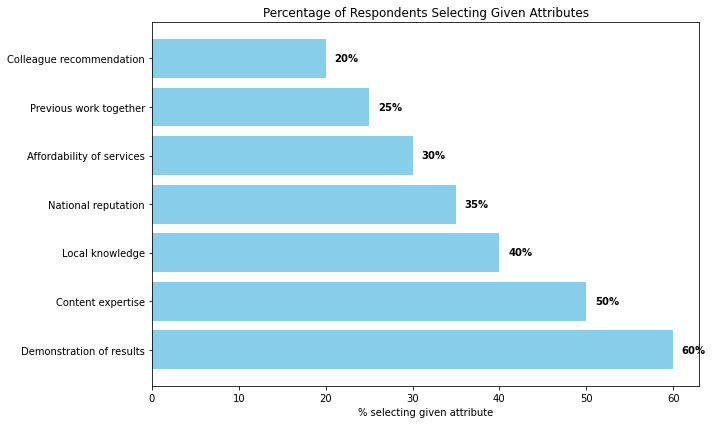

In [55]:
attributes = ['Demonstration of results', 'Content expertise', 'Local knowledge', 
              'National reputation', 'Affordability of services', 
              'Previous work together', 'Colleague recommendation']
percentages = [60, 50, 40, 35, 30, 25, 20]

# Create the plot
plt.figure(figsize=(10, 6))
plt.barh(attributes, percentages, color='skyblue')
plt.xlabel('% selecting given attribute')
plt.title('Percentage of Respondents Selecting Given Attributes')

# Adding the percentage labels on the bars
for index, value in enumerate(percentages):
    plt.text(value + 1, index, f'{value}%', va='center', fontweight='bold')

# Show the plot
plt.tight_layout()
plt.show()